## Yelp 프랜차이즈 경쟁압력 분석
### STEP 0: 데이터 로드 및 전처리
### STEP 1: 지역/업종 선정
### STEP 2: 프랜차이즈 판정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import folium
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
### STEP 0 - 데이터 로드 및 기본 전처리

In [5]:
# 경로 설정
BUSINESS_PATH = r'C:\Users\seonu\Documents\yelp-franchise-analysis\dataset\yelp_dataset\yelp_business.csv'
REVIEW_PATH   = r'C:\Users\seonu\Documents\yelp-franchise-analysis\dataset\yelp_dataset\yelp_review.csv'

# 데이터 로드
business_raw = pd.read_csv(BUSINESS_PATH)
review_raw   = pd.read_csv(REVIEW_PATH)

print(f'business: {business_raw.shape}')
print(f'review  : {review_raw.shape}')

business: (174567, 13)
review  : (5261668, 9)


In [6]:
# 기본 구조 확인
print('=== business 컬럼 ===')
print(business_raw.columns.tolist())
print()
print('=== review 컬럼 ===')
print(review_raw.columns.tolist())

=== business 컬럼 ===
['business_id', 'name', 'neighborhood', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'categories']

=== review 컬럼 ===
['review_id', 'user_id', 'business_id', 'stars', 'date', 'text', 'useful', 'funny', 'cool']


In [7]:
# 결측치 확인
print('=== business 결측치 ===')
print(business_raw[['business_id', 'name', 'city', 'state',
                     'latitude', 'longitude', 'stars',
                     'review_count', 'categories']].isnull().sum())
print()
print('=== review 결측치 ===')
print(review_raw[['review_id', 'business_id', 'stars', 'text', 'date']].isnull().sum())

=== business 결측치 ===
business_id     0
name            0
city            1
state           1
latitude        1
longitude       1
stars           0
review_count    0
categories      0
dtype: int64

=== review 결측치 ===
review_id      0
business_id    0
stars          0
text           0
date           0
dtype: int64


In [8]:
# 필수 컬럼 결측치 제거
business = business_raw.dropna(
    subset=['latitude', 'longitude', 'stars', 'review_count', 'categories', 'name']
).copy()

review = review_raw.dropna(
    subset=['business_id', 'stars', 'text']
).copy()

# 날짜 변환
review['date'] = pd.to_datetime(review['date'])

print(f'business 전처리 후: {business.shape}  (제거: {len(business_raw) - len(business)}행)')
print(f'review   전처리 후: {review.shape}  (제거: {len(review_raw) - len(review)}행)')

business 전처리 후: (174566, 13)  (제거: 1행)
review   전처리 후: (5261668, 9)  (제거: 0행)


In [9]:
# 기본 통계 확인
print('=== business 기본 통계 ===')
business[['stars', 'review_count']].describe().round(2)

=== business 기본 통계 ===


,stars,review_count
count,174566.00,174566.00
mean,3.63,30.14
std,1.00,98.21
min,1.00,3.00
25%,3.00,4.00
50%,3.50,8.00
75%,4.50,23.00
max,5.00,7361.00


**STEP 0 결과 요약**:

- business: 174,567행 → 결측치 1행 제거 → 174,566행
- review: 5,261,668행 → 결측치 없음 → 그대로
- 평균 별점 3.63, 평균 리뷰수 30개 (중앙값 8개, 최대 7,361개)
- review_count 편차 엄청 큼 (std 98) → 로그 스케일링 필요성 확인됨

---
## STEP 1 — 지역/업종 선정

**목표**: 분석에 최적인 도시와 업종 조합을 데이터 기반으로 선정한다.

**선정 기준**:
- 업체 수가 충분할 것 (텍스트 분석 볼륨 확보)
- 프랜차이즈와 독립 브랜드가 혼재할 것 (FPI 분석 전제 조건)
- 상권이 밀집되어 있을 것 (거리 기반 FPI 효과 측정 가능)

**진행 순서**:
1. 주(state)별 → 도시별 업체 수 확인으로 후보 도시 선정
2. 후보 도시 내 업종별 프랜차이즈 비율 확인으로 업종 선정
3. 후보 도시 3개 지도 시각화로 밀집도 및 혼재 정도 비교
4. 최종 지역/업종 확정

### 1-1. 주(state)별 업체 수 확인

전체 데이터에서 주별 업체 수를 집계해 분석 가능한 규모의 지역을 추린다.

In [51]:
state_counts = business['state'].value_counts().head(20)
print('=== state별 업체 수 상위 20 ===')
print(state_counts)

=== state별 업체 수 상위 20 ===
state
AZ     52214
NV     33086
ON     30207
NC     12956
OH     12609
PA     10109
QC      8169
WI      4754
EDH     3795
BW      3118
IL      1852
SC       679
MLN      208
HLD      179
NYK      152
CHE      143
FIF       85
ELN       47
WLN       38
C         28
Name: count, dtype: int64


**결과 해석**: AZ(52,214), NV(33,086), ON(30,207) 순으로 많다. ON은 캐나다(토론토)로 외식 문화 맥락이 달라 제외. **AZ, NV, NC**를 후보 주로 선정한다.

### 1-2. 도시별 업체 수 확인

후보 주 내에서 구체적인 도시를 추린다.

In [52]:
city_counts = business.groupby(['state', 'city'])['business_id'].count()\
                       .sort_values(ascending=False).head(20)
print('=== 도시별 업체 수 상위 20 ===')
print(city_counts)

=== 도시별 업체 수 상위 20 ===
state  city       
NV     Las Vegas      26764
AZ     Phoenix        17213
ON     Toronto        17204
NC     Charlotte       8553
AZ     Scottsdale      8227
PA     Pittsburgh      6354
AZ     Mesa            5759
QC     Montréal        5709
NV     Henderson       4463
AZ     Tempe           4263
       Chandler        3993
EDH    Edinburgh       3704
OH     Cleveland       3322
WI     Madison         3213
AZ     Glendale        3206
       Gilbert         3128
ON     Mississauga     2726
BW     Stuttgart       2000
AZ     Peoria          1706
ON     Markham         1564
Name: business_id, dtype: int64


**결과 해석**: Las Vegas(26,764), Phoenix(17,213), Charlotte(8,553)가 각 주의 대표 도시로 확인된다. 이 3개 도시를 후보로 선정해 상세 비교를 진행한다.

### 1-2-1. 도시별 전체 리뷰수 확인

업체 수와 함께 리뷰수도 확인한다. 리뷰수는 텍스트 분석 볼륨에 직결되는 지표로, 업체 수와 함께 후보 도시 선정의 핵심 기준이다.

In [71]:
# 전체 도시별 리뷰수 합계 상위 20
review_all = review.merge(
    business[['business_id', 'city', 'state']], on='business_id', how='left'
)

review_counts_all = review_all.groupby(['state', 'city'])['review_id'].count()\
                               .sort_values(ascending=False).head(20)
print('=== 전체 도시별 리뷰수 상위 20 ===')
print(review_counts_all)

=== 전체 도시별 리뷰수 상위 20 ===
state  city           
NV     Las Vegas          1603616
AZ     Phoenix             576700
ON     Toronto             430957
AZ     Scottsdale          308564
NC     Charlotte           237308
PA     Pittsburgh          179515
NV     Henderson           166862
AZ     Tempe               162782
       Mesa                130875
QC     Montréal            122613
AZ     Chandler            122326
       Gilbert              97246
OH     Cleveland            92314
WI     Madison              86624
AZ     Glendale             76293
EDH    Edinburgh            47162
ON     Mississauga          43157
AZ     Peoria               42574
ON     Markham              38841
NV     North Las Vegas      37921
Name: review_id, dtype: int64


**결과 해석**: Las Vegas(1,603,616개)가 2위 Phoenix(576,700개)의 2.8배로 압도적 1위다. 업체 수 기준과 리뷰수 기준 모두 Las Vegas가 1위로 일치한다. Las Vegas, Phoenix, Charlotte을 후보 도시로 선정한다.

### 1-3. 도시별 업체 수 시각화

In [53]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

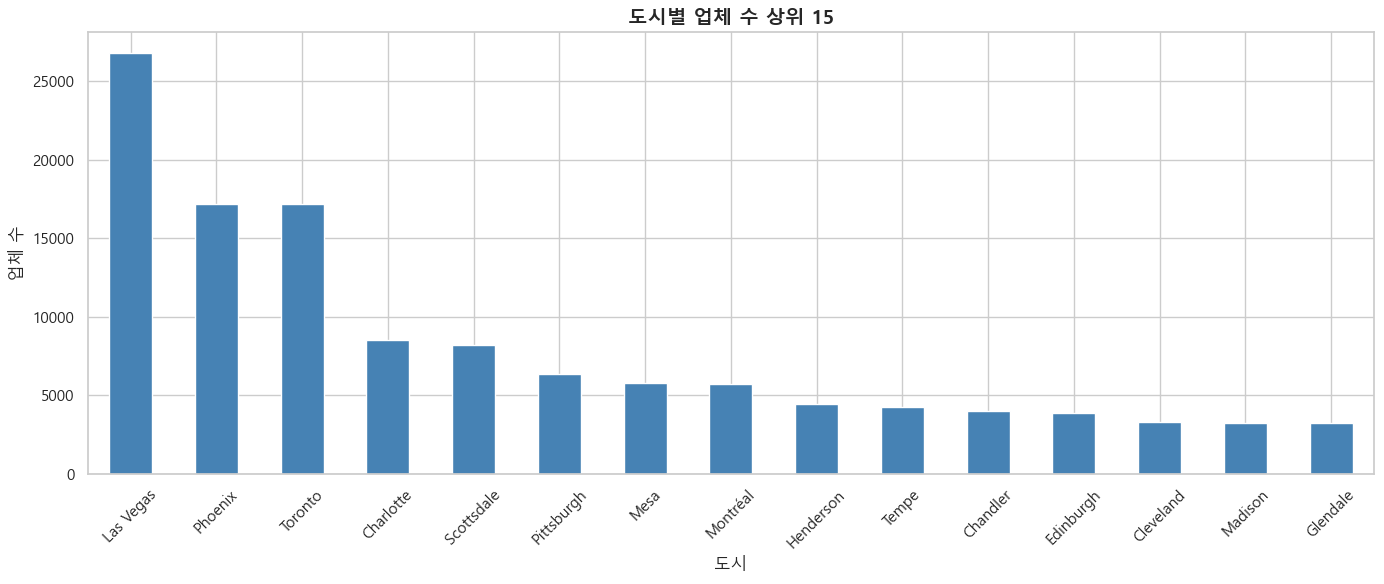

In [54]:
top_cities = business.groupby('city')['business_id'].count()\
                     .sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 6))
top_cities.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('도시별 업체 수 상위 15', fontsize=14, fontweight='bold')
ax.set_xlabel('도시')
ax.set_ylabel('업체 수')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 1-4. 업종 선정 — Las Vegas 기준 프랜차이즈 비율 높은 업종 확인

업체 수가 가장 높은 **Las Vegas 전체 업체 기준으로 프랜차이즈 비율이 높은 업종**을 데이터로 확인한다.

- 업체 수 50개 미만 희소 업종 제외
- 프랜차이즈 판정 기준: 동일 브랜드명 10개 이상 출현 (임시 적용)

In [66]:
import re

def clean_name(name):
    name = name.lower().strip()
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

# Las Vegas 전체 업체 (카테고리 제한 없이)
biz_lv = business[
    (business['state'] == 'NV') &
    (business['city'] == 'Las Vegas')
].copy()

biz_lv['name_clean'] = biz_lv['name'].apply(clean_name)
brand_cnt_lv = biz_lv.groupby('name_clean')['business_id'].count()
fc_brands_lv = brand_cnt_lv[brand_cnt_lv >= 10].index
biz_lv['is_franchise'] = biz_lv['name_clean'].isin(fc_brands_lv)

cat_exploded = biz_lv.assign(
    cat=biz_lv['categories'].str.split(';')
).explode('cat')
cat_exploded['cat'] = cat_exploded['cat'].str.strip()

cat_stats = cat_exploded.groupby('cat').agg(
    total=('business_id', 'count'),
    franchise=('is_franchise', 'sum')
).reset_index()
cat_stats['franchise_ratio'] = cat_stats['franchise'] / cat_stats['total'] * 100
cat_stats = cat_stats[cat_stats['total'] >= 50].sort_values('franchise_ratio', ascending=False)

print('=== 프랜차이즈 비율 높은 업종 상위 20 ===')
print(cat_stats[['cat', 'total', 'franchise', 'franchise_ratio']].head(20).to_string(index=False))

=== 프랜차이즈 비율 높은 업종 상위 20 ===
                          cat  total  franchise  franchise_ratio
                    Fast Food    884        615        69.570136
        Banks & Credit Unions    244        163        66.803279
           Convenience Stores    304        201        66.118421
                   Drugstores    208        135        64.903846
             Shipping Centers    132         84        63.636364
Photography Stores & Services     88         48        54.545455
                      Tex-Mex     75         38        50.666667
                     Notaries     95         48        50.526316
                 Gas Stations    278        138        49.640288
                      Burgers    531        225        42.372881
  Check Cashing/Pay-day Loans     76         32        42.105263
                   Sandwiches    655        261        39.847328
                Mobile Phones    190         73        38.421053
                       Donuts     79         30        37.974

In [65]:
# Restaurants 카테고리 직접 확인
print(cat_stats[cat_stats['cat'] == 'Restaurants'])

             cat  total  franchise  franchise_ratio
870  Restaurants   5899        937        15.884048


**결과 해석 및 업종 선정**:

| 업종 | 전체 | 프랜차이즈 비율 | 독립 브랜드 수 |
|---|---|---|---|
| Fast Food | 884 | 69.6% | 269개 |
| Burgers | 531 | 42.4% | 306개 |
| Sandwiches | 655 | 39.8% | 394개 |
| Coffee & Tea | 505 | 35.6% | 325개 |
| **Restaurants** | 5,899 | 15.7% | 4,974개 |

Fast Food, Burgers 등 프랜차이즈 비율이 높은 업종은 **독립 브랜드 절대 수가 너무 적어** 생존 브랜드 분석 시 표본 부족 문제가 발생한다.

Restaurants는 프랜차이즈 비율이 낮아 보이지만 **925개 프랜차이즈 + 4,974개 독립 브랜드**로 분석 볼륨이 압도적이며, 대형 프랜차이즈가 포함되어 FPI 효과 측정에 충분하다.

> **업종 확정: Restaurants**

### 1-5. 후보 도시 3개 비교 — 지도 시각화

업종(Restaurants)을 고정한 상태에서 **Las Vegas / Phoenix / Charlotte** 3개 도시를 비교한다.

- 산점도 지도: 프랜차이즈(빨강) vs 독립 브랜드(파랑) 혼재 정도 확인
- 히트맵: 리뷰수 기반 상권 밀집도 확인

In [56]:
import plotly.express as px

CANDIDATES = [
    {'state': 'NV', 'city': 'Las Vegas'},
    {'state': 'AZ', 'city': 'Phoenix'},
    {'state': 'NC', 'city': 'Charlotte'},
]
TARGET_CATEGORY = 'Restaurants'
FRANCHISE_THRESHOLD = 10

city_data = {}
for c in CANDIDATES:
    city, state = c['city'], c['state']
    df = business[
        (business['state'] == state) &
        (business['city'] == city) &
        (business['categories'].str.contains(TARGET_CATEGORY, na=False))
    ].copy()
    df['name_clean'] = df['name'].apply(clean_name)
    brand_cnt = df.groupby('name_clean')['business_id'].count()
    fc_brands = brand_cnt[brand_cnt >= FRANCHISE_THRESHOLD].index
    df['is_franchise'] = df['name_clean'].isin(fc_brands)
    df['type'] = df['is_franchise'].map({True: '프랜차이즈', False: '독립 브랜드'})
    city_data[city] = df
    n_fc = df['is_franchise'].sum()
    n_indie = (~df['is_franchise']).sum()
    print(f'{city:12} | 전체: {len(df):,}개 | 프랜차이즈: {n_fc:,}개 ({n_fc/len(df)*100:.1f}%) | 독립: {n_indie:,}개 ({n_indie/len(df)*100:.1f}%)')

Las Vegas    | 전체: 5,899개 | 프랜차이즈: 925개 (15.7%) | 독립: 4,974개 (84.3%)
Phoenix      | 전체: 3,647개 | 프랜차이즈: 592개 (16.2%) | 독립: 3,055개 (83.8%)
Charlotte    | 전체: 2,460개 | 프랜차이즈: 304개 (12.4%) | 독립: 2,156개 (87.6%)


In [57]:
summary = []
for city, df in city_data.items():
    n_fc = df['is_franchise'].sum()
    n_indie = (~df['is_franchise']).sum()
    summary.append({
        '도시': city,
        '전체 업체수': len(df),
        '프랜차이즈': n_fc,
        '독립 브랜드': n_indie,
        '프랜차이즈 비율(%)': round(n_fc / len(df) * 100, 1),
        '평균 별점': round(df['stars'].mean(), 2),
        '평균 리뷰수': round(df['review_count'].mean(), 0),
    })
summary_df = pd.DataFrame(summary)
print('=== 후보 도시 비교 요약 ===')
print(summary_df.to_string(index=False))

=== 후보 도시 비교 요약 ===
       도시  전체 업체수  프랜차이즈  독립 브랜드  프랜차이즈 비율(%)  평균 별점  평균 리뷰수
Las Vegas    5899    925    4974         15.7   3.46   158.0
  Phoenix    3647    592    3055         16.2   3.43    91.0
Charlotte    2460    304    2156         12.4   3.39    64.0


In [61]:
colors = {'프랜차이즈': '#E74C3C', '독립 브랜드': '#3498DB'}

for city, df in city_data.items():
    fig = px.scatter_mapbox(
        df, lat='latitude', lon='longitude',
        color='type', color_discrete_map=colors,
        hover_name='name',
        hover_data={'stars': True, 'review_count': True, 'type': True,
                    'latitude': False, 'longitude': False},
        zoom=11, height=550,
        title=f'{city} | 전체 {len(df):,}개 | 프랜차이즈 {df["is_franchise"].sum()}개({df["is_franchise"].mean()*100:.1f}%) | 독립 {(~df["is_franchise"]).sum()}개'
    )
    fig.update_layout(mapbox_style='open-street-map',
                      margin={'r': 0, 't': 50, 'l': 0, 'b': 0}, width=900)
    fig.update_traces(marker=dict(size=6, opacity=0.7))
    fig.write_html(f'map_{city.lower().replace(" ","_")}_scatter.html')
    fig.update_layout(width=600, height=600)
    fig.show()
    print()

In [62]:
for city, df in city_data.items():
    fig = px.density_mapbox(
        df, lat='latitude', lon='longitude',
        z='review_count', radius=20, zoom=11, height=500,
        color_continuous_scale='YlOrRd',
        title=f'{city} - 밀집도 히트맵 (리뷰수 기반)'
    )
    fig.update_layout(mapbox_style='open-street-map',
                      margin={'r': 0, 't': 50, 'l': 0, 'b': 0}, width=900)
    fig.write_html(f'map_{city.lower().replace(" ","_")}_heatmap.html')
    fig.update_layout(width=600, height=600)
    fig.show()
    print()

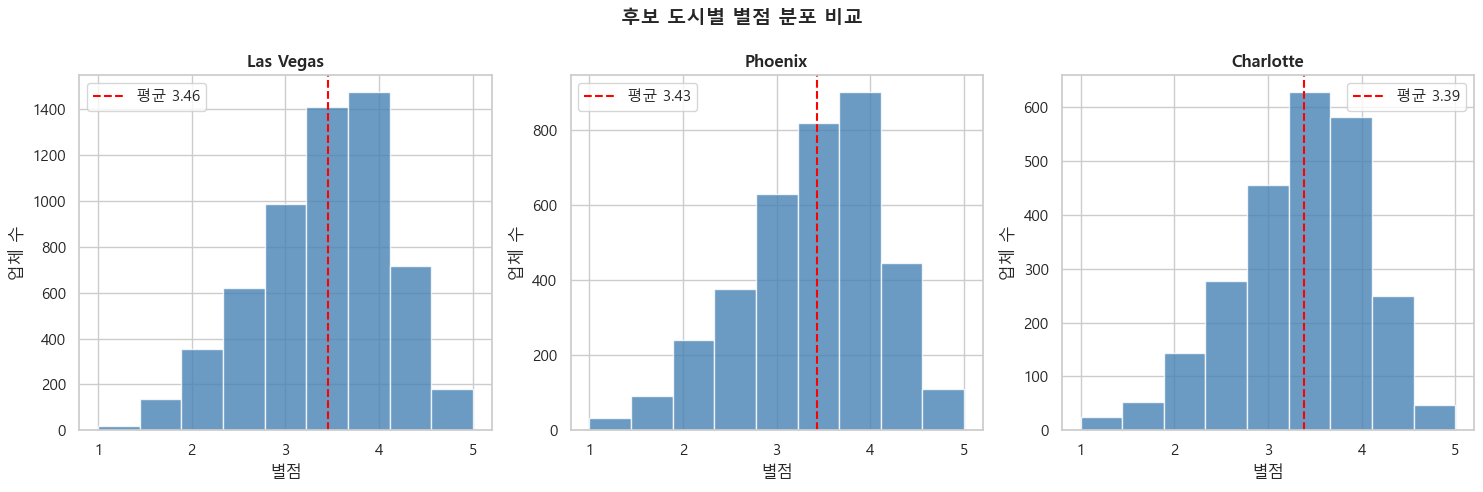

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (city, df) in zip(axes, city_data.items()):
    df['stars'].hist(ax=ax, bins=9, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df['stars'].mean(), color='red', linestyle='--',
               label=f'평균 {df["stars"].mean():.2f}')
    ax.set_title(f'{city}', fontweight='bold')
    ax.set_xlabel('별점')
    ax.set_ylabel('업체 수')
    ax.legend()
plt.suptitle('후보 도시별 별점 분포 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1-6. 최종 지역/업종 확정

**지도 및 수치 비교 결과**:

| 기준 | Las Vegas | Phoenix | Charlotte |
|---|---|---|---|
| 전체 업체수 | **5,899개** | 3,647개 | 2,460개 |
| 프랜차이즈 비율 | 15.7% | **16.2%** | 12.4% |
| 독립 브랜드 수 | **4,974개** | 3,055개 | 2,156개 |
| 평균 별점 | **3.46** | 3.43 | 3.39 |
| 평균 리뷰수 | **158개** | 91개 | 64개 |
| 상권 밀집 패턴 | 스트립 중심 고밀집 | 격자형 분산 | 다운타운 집중 |

**Las Vegas 선정 이유**:
- 업체 수, 리뷰수 모두 압도적 → 텍스트 분석 볼륨 확보
- 스트립(Paradise 구역) 중심 밀집 + 외곽 분산 구조 → FPI 거리 효과 측정에 최적
- 프랜차이즈/독립 브랜드 혼재 비율 균형적 (15.7% vs 84.3%)

> **최종 확정: Las Vegas (NV) / Restaurants**

In [69]:
TARGET_STATE    = 'NV'
TARGET_CITY     = 'Las Vegas'
TARGET_CATEGORY = 'Restaurants'

biz_target = city_data[TARGET_CITY].copy()

print('=' * 40)
print('STEP 1 완료 — 분석 대상 확정')
print('=' * 40)
print(f'지역  : {TARGET_CITY}, {TARGET_STATE}')
print(f'업종  : {TARGET_CATEGORY}')
print(f'업체수: {len(biz_target):,}개')

STEP 1 완료 — 분석 대상 확정
지역  : Las Vegas, NV
업종  : Restaurants
업체수: 5,899개


---
## STEP 2 - 프랜차이즈 판정

In [72]:
# 2-1. 브랜드명 정제
import re

def clean_name(name):
    name = name.lower().strip()
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

biz_target['name_clean'] = biz_target['name'].apply(clean_name)

print('브랜드명 정제 완료')
print(biz_target[['name', 'name_clean']].head(10))

브랜드명 정제 완료
                                      name  \
52               "Flight Deck Bar & Grill"   
53                                "Subway"   
54                             "GameWorks"   
91                        "Cafe Mastrioni"   
122                           "McDonald's"   
133  "Divine Cafe at the Springs Preserve"   
145                               "Subway"   
177                 "Geebee's Bar & Grill"   
274                     "Trattoria Italia"   
303                   "Cancun Bar & Grill"   

                              name_clean  
52                 flight deck bar grill  
53                                subway  
54                             gameworks  
91                        cafe mastrioni  
122                            mcdonalds  
133  divine cafe at the springs preserve  
145                               subway  
177                    geebees bar grill  
274                     trattoria italia  
303                     cancun bar grill  


In [73]:
# 2-2. 브랜드별 출현 횟수 집계
brand_counts = biz_target.groupby('name_clean')['business_id'].count()\
                          .sort_values(ascending=False)

print('=== 브랜드 출현 횟수 상위 20 ===')
print(brand_counts.head(20))

=== 브랜드 출현 횟수 상위 20 ===
name_clean
subway                       117
mcdonalds                     90
robertos taco shop            44
panda express                 41
jack in the box               40
taco bell                     40
burger king                   40
pizza hut                     35
pts                           33
port of subs                  31
del taco                      29
carls jr                      28
capriottis sandwich shop      23
wendys                        23
dennys                        21
popeyes louisiana kitchen     21
kfc                           20
chipotle mexican grill        20
el pollo loco                 20
dominos pizza                 19
Name: business_id, dtype: int64


In [74]:
# 2-3. 민감도 분석 - 기준별 프랜차이즈 수 비교
thresholds = [3, 5, 10, 15, 20]
print('=== 프랜차이즈 판정 기준별 결과 ===')
print(f'{"기준":>6} | {"프랜차이즈 브랜드 수":>18} | {"프랜차이즈 업체 수":>18} | {"비율":>6}')
print('-' * 60)
for thr in thresholds:
    fc_brands = brand_counts[brand_counts >= thr]
    fc_biz    = biz_target[biz_target['name_clean'].isin(fc_brands.index)]
    ratio     = len(fc_biz) / len(biz_target) * 100
    print(f'{thr:>6} | {len(fc_brands):>18} | {len(fc_biz):>18} | {ratio:>5.1f}%')

=== 프랜차이즈 판정 기준별 결과 ===
    기준 |        프랜차이즈 브랜드 수 |         프랜차이즈 업체 수 |     비율
------------------------------------------------------------
     3 |                186 |               1582 |  26.8%
     5 |                 85 |               1245 |  21.1%
    10 |                 35 |                925 |  15.7%
    15 |                 23 |                783 |  13.3%
    20 |                 19 |                716 |  12.1%


In [75]:
# ★ 기준 확정 (민감도 분석 결과 보고 수정)
FRANCHISE_THRESHOLD = 10

franchise_brands = brand_counts[brand_counts >= FRANCHISE_THRESHOLD].index
biz_target['is_franchise'] = biz_target['name_clean'].isin(franchise_brands)

n_franchise = biz_target['is_franchise'].sum()
n_indie     = (~biz_target['is_franchise']).sum()

print(f'판정 기준: {FRANCHISE_THRESHOLD}개 이상')
print(f'프랜차이즈 업체: {n_franchise}개 ({n_franchise/len(biz_target)*100:.1f}%)')
print(f'독립 브랜드:     {n_indie}개 ({n_indie/len(biz_target)*100:.1f}%)')

판정 기준: 10개 이상
프랜차이즈 업체: 925개 (15.7%)
독립 브랜드:     4974개 (84.3%)


In [76]:
# 2-4. 프랜차이즈 vs 독립 브랜드 성과 비교
compare = biz_target.groupby('is_franchise')[['stars', 'review_count']].agg(['mean', 'median'])
compare.index = ['독립 브랜드', '프랜차이즈']
print('=== 프랜차이즈 vs 독립 브랜드 기본 비교 ===')
print(compare.round(2))

=== 프랜차이즈 vs 독립 브랜드 기본 비교 ===
       stars        review_count       
        mean median         mean median
독립 브랜드  3.60    3.5       180.06   57.0
프랜차이즈   2.67    2.5        36.73   24.0


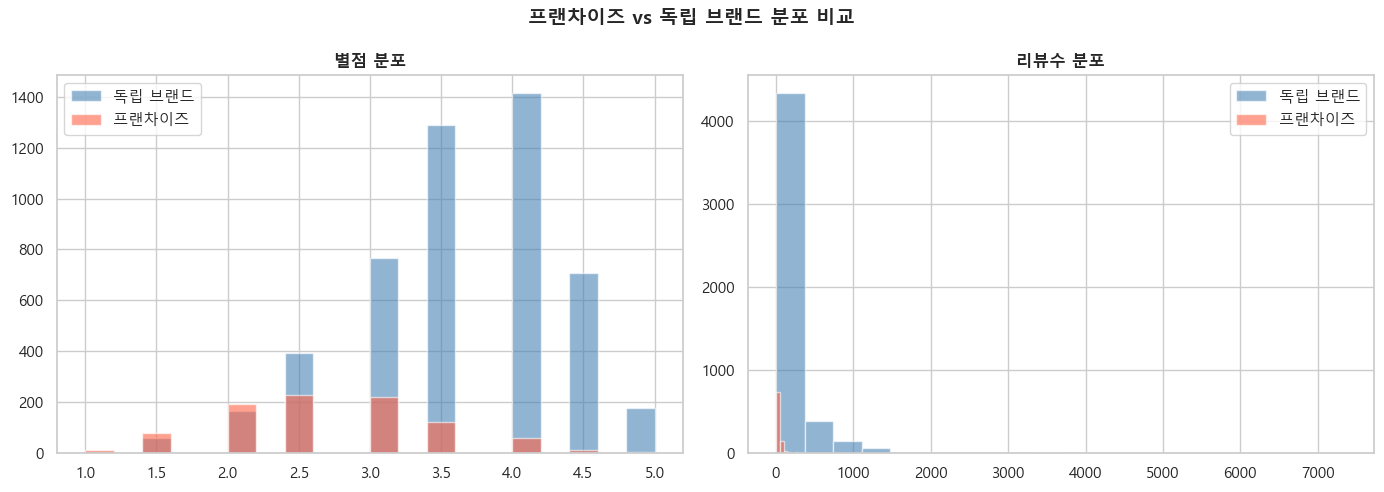

In [77]:
# 2-5. 시각화 - 별점 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['stars', 'review_count'],
    ['별점 분포', '리뷰수 분포']
):
    biz_target[biz_target['is_franchise'] == False][col].hist(
        ax=ax, bins=20, alpha=0.6, label='독립 브랜드', color='steelblue'
    )
    biz_target[biz_target['is_franchise'] == True][col].hist(
        ax=ax, bins=20, alpha=0.6, label='프랜차이즈', color='tomato'
    )
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('프랜차이즈 vs 독립 브랜드 분포 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [78]:
# 2-6. 지도 시각화 - 프랜차이즈/독립 브랜드 위치
m2 = folium.Map(location=[center_lat, center_lon], zoom_start=12)

sample2 = biz_target.sample(min(500, len(biz_target)), random_state=42)
for _, row in sample2.iterrows():
    color = 'tomato' if row['is_franchise'] else 'steelblue'
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['name']} ({'프랜차이즈' if row['is_franchise'] else '독립'})"
    ).add_to(m2)

m2.save('step2_franchise_map.html')
print('지도 저장 완료: step2_franchise_map.html')
print('빨강: 프랜차이즈 / 파랑: 독립 브랜드')
m2

지도 저장 완료: step2_franchise_map.html
빨강: 프랜차이즈 / 파랑: 독립 브랜드


In [79]:
# 2-7. 리뷰 데이터와 병합
review_target = review[
    review['business_id'].isin(biz_target['business_id'])
].copy()

print(f'분석 대상 리뷰 수: {len(review_target):,}개')
print(f'분석 대상 업체 수: {review_target["business_id"].nunique():,}개')

분석 대상 리뷰 수: 929,606개
분석 대상 업체 수: 5,899개


In [ ]:
# 최종 데이터 저장
biz_target.to_csv('dataset/biz_target.csv', index=False)
review_target.to_csv('dataset/review_target.csv', index=False)

print('저장 완료')
print(f'biz_target.csv    : {len(biz_target):,}행')
print(f'review_target.csv : {len(review_target):,}행')
print()
print('=== STEP 0,1,2 완료 ===')
print(f'분석 지역  : {TARGET_CITY}, {TARGET_STATE}')
print(f'분석 업종  : {TARGET_CATEGORY}')
print(f'프랜차이즈 기준: {FRANCHISE_THRESHOLD}개 이상')
print(f'전체 업체  : {len(biz_target):,}개')
print(f'프랜차이즈 : {n_franchise:,}개')
print(f'독립 브랜드: {n_indie:,}개')